# Day 09：翻译的艺术 —— 序列到序列模型> ⏳ 第十周 · 记忆的诞生 · 第 9 天昨天我们让 LSTM 学会了"续写"——但续写只是"自己说自己的话"。更难的任务是：**听完一句话，翻译成另一句话**。这需要网络先"听懂"整句话，再"逐字翻译"。这就是**序列到序列（Seq2Seq）模型**——机器翻译的基石。**今天的任务**：1. 理解 Encoder-Decoder 架构2. 用代码实现一个迷你 Seq2Seq 翻译模型3. 认识 Seq2Seq 的瓶颈问题——引出注意力机制---

## 1. 历史剧场：2014 年的翻译革命2014 年，Sutskever 等人发表了《Sequence to Sequence Learning with Neural Networks》，首次用 Encoder-Decoder 架构实现了神经机器翻译。在此之前，机器翻译靠的是人工编写的规则和统计模型——效果差，维护难。Seq2Seq 的核心思想：> **用一个 LSTM 把源语言"压缩"成一个向量，再用另一个 LSTM 把这个向量"解压"成目标语言。**这个想法简洁而强大，直接催生了 Google Translate 2016 年的大升级。---

## 2. 生活隐喻：同声传译的两步走- **Encoder（编码器）**：像听外语的翻译官——认真听完一整句话，把意思记在脑子里- **Context Vector（上下文向量）**：翻译官脑子里的"理解"——一句话的压缩表示- **Decoder（解码器）**：像说中文的翻译官——根据脑子里的理解，逐字翻译出来

<p align="center">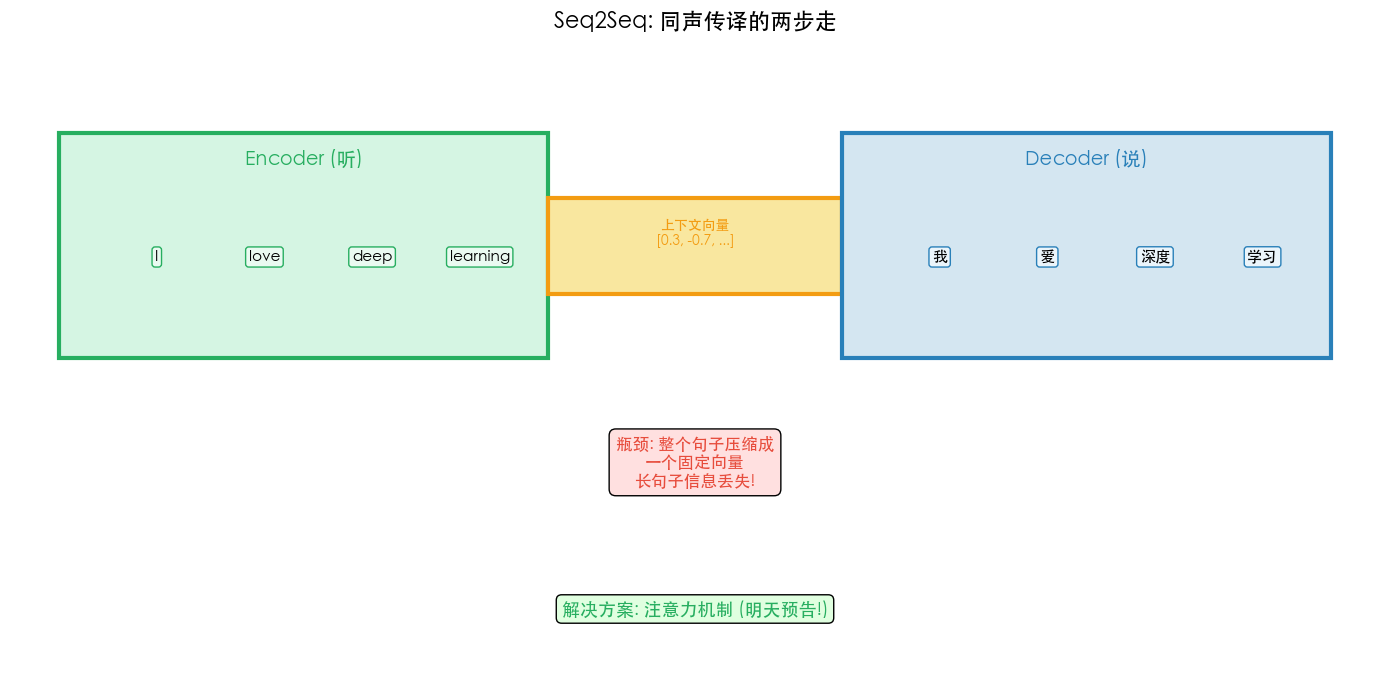</p>*Seq2Seq 信息瓶颈示意图*

源语言: "I love deep learning"  ↓ Encoder (听)上下文向量: [0.3, -0.7, 0.5, ...]  ↓ Decoder (说)目标语言: "我 爱 深度 学习"

---

## 3. 代码实验室：迷你 Seq2Seq 翻译

In [ ]:
import torchimport torch.nn as nnimport matplotlib.pyplot as pltimport numpy as npplt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei']plt.rcParams['axes.unicode_minus'] = False

### 3.1 构建迷你翻译数据

In [ ]:
pairs = [    ("我 喜欢 猫", "I like cats"),    ("我 喜欢 狗", "I like dogs"),    ("我 爱 深度 学习", "I love deep learning"),    ("他 喜欢 音乐", "He likes music"),    ("她 爱 编程", "She loves coding"),    ("猫 喜欢 鱼", "Cats like fish"),    ("狗 喜欢 骨头", "Dogs like bones"),    ("他 爱 读书", "He loves reading"),]def build_vocab(sentences):    chars = set()    for s in sentences:        chars.update(s.split() if ' ' in s else list(s))    chars = ['<PAD>', '<SOS>', '<EOS>'] + sorted(chars)    return {c: i for i, c in enumerate(chars)}, charssrc_sents = [p[0] for p in pairs]tgt_sents = [p[1] for p in pairs]src_vocab, src_chars = build_vocab(src_sents)tgt_vocab, tgt_chars = build_vocab(tgt_sents)print(f"源语言词汇: {len(src_vocab)} 个")print(f"目标语言词汇: {len(tgt_vocab)} 个")

### 3.2 定义 Encoder 和 Decoder

In [ ]:
class Encoder(nn.Module):    def __init__(self, vocab_size, embed_dim, hidden_dim):        super().__init__()        self.embedding = nn.Embedding(vocab_size, embed_dim)        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)    def forward(self, x):        emb = self.embedding(x)        _, (h_n, c_n) = self.lstm(emb)        return h_n, c_nclass Decoder(nn.Module):    def __init__(self, vocab_size, embed_dim, hidden_dim):        super().__init__()        self.embedding = nn.Embedding(vocab_size, embed_dim)        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)        self.fc = nn.Linear(hidden_dim, vocab_size)    def forward(self, x, h_n, c_n):        emb = self.embedding(x)        out, (h_n, c_n) = self.lstm(emb, (h_n, c_n))        logits = self.fc(out)        return logits, h_n, c_n

### 3.3 训练 Seq2Seq

In [ ]:
embed_dim = 16hidden_dim = 32encoder = Encoder(len(src_vocab), embed_dim, hidden_dim)decoder = Decoder(len(tgt_vocab), embed_dim, hidden_dim)optimizer = torch.optim.Adam(list(encoder.parameters()) + list(decoder.parameters()), lr=0.01)loss_fn = nn.CrossEntropyLoss(ignore_index=0)def encode_sentence(sent, vocab, max_len=6):    tokens = sent.split()    indices = [vocab.get(t, 0) for t in tokens]    indices = indices + [0] * (max_len - len(indices))    return torch.tensor([indices], dtype=torch.long)losses = []for epoch in range(500):    total_loss = 0    for src, tgt in pairs:        src_tensor = encode_sentence(src, src_vocab)        tgt_tokens = tgt.split()        tgt_indices = [tgt_vocab['<SOS>']] + [tgt_vocab.get(t, 0) for t in tgt_tokens] + [tgt_vocab['<EOS>']]        tgt_tensor = torch.tensor([tgt_indices], dtype=torch.long)        h_n, c_n = encoder(src_tensor)        loss = 0        for i in range(len(tgt_indices) - 1):            input_tok = tgt_tensor[:, i:i+1]            logits, h_n, c_n = decoder(input_tok, h_n, c_n)            target = tgt_tensor[:, i+1]            loss += loss_fn(logits.squeeze(1), target)        optimizer.zero_grad()        loss.backward()        optimizer.step()        total_loss += loss.item()    losses.append(total_loss / len(pairs))print("训练完成!")

### 3.4 测试翻译

In [ ]:
def translate(encoder, decoder, src_sentence, max_len=10):    src_tensor = encode_sentence(src_sentence, src_vocab)    h_n, c_n = encoder(src_tensor)    current = torch.tensor([[tgt_vocab['<SOS>']]], dtype=torch.long)    result = []    for _ in range(max_len):        logits, h_n, c_n = decoder(current, h_n, c_n)        next_idx = logits.argmax(dim=-1).item()        if next_idx == tgt_vocab['<EOS>']:            break        result.append(tgt_chars[next_idx])        current = torch.tensor([[next_idx]], dtype=torch.long)    return ' '.join(result)for src, tgt in pairs[:4]:    pred = translate(encoder, decoder, src)    print(f"源: {src}")    print(f"真: {tgt}")    print(f"预: {pred}")    print()

### 3.5 可视化训练

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(8, 5))ax.plot(losses, color='#3498db', alpha=0.8)ax.set_xlabel('Epoch', fontsize=12)ax.set_ylabel('Loss', fontsize=12)ax.set_title('Seq2Seq 翻译模型训练损失', fontsize=14)ax.grid(True, alpha=0.3)plt.tight_layout()plt.show()

---

## 4. Seq2Seq 的致命瓶颈Seq2Seq 有一个根本性的问题：**整个源句子被压缩成一个固定长度的向量**。短句子没问题，但长句子呢？一个向量能装下 50 个词的信息吗？

"I went to the store yesterday and bought some milk, then I visited my friend who lives near the park, and we had dinner at a restaurant that serves Italian food"  ↓ 压缩成一个向量[0.3, -0.7, 0.5, ...]  ← 信息严重丢失！  ↓ 解压"我昨天去了商店..."  ← 后面的内容翻译不出来

这就是**信息瓶颈问题**——也是下一阶段"注意力机制"要解决的核心问题。---

## 今日结语今天我们实现了 Seq2Seq 翻译模型：Encoder 把源语言压缩成向量，Decoder 把向量解压成目标语言。但 Seq2Seq 有一个致命瓶颈：**长句子无法被一个固定向量完全表示**。翻译官的"脑子"容量有限，句子太长就记不住了。有没有办法让翻译官在翻译每个词时，都能"回头看"源句子的不同部分？> 这就是**注意力机制**——下一阶段的主角。---### 翻译词典| 生活中的直觉 | 深度学习术语 ||---|---|| 同声传译的两步走 | Encoder-Decoder 架构 || 听完一整句再翻译 | 编码器压缩源序列 || 根据理解逐字翻译 | 解码器生成目标序列 || 脑子里的"理解" | 上下文向量——源序列的压缩表示 || 脑子容量有限记不住长句 | 信息瓶颈——固定向量无法表示长序列 || 翻译时回头看原文 | 注意力机制（预告！） |